      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             ₹39

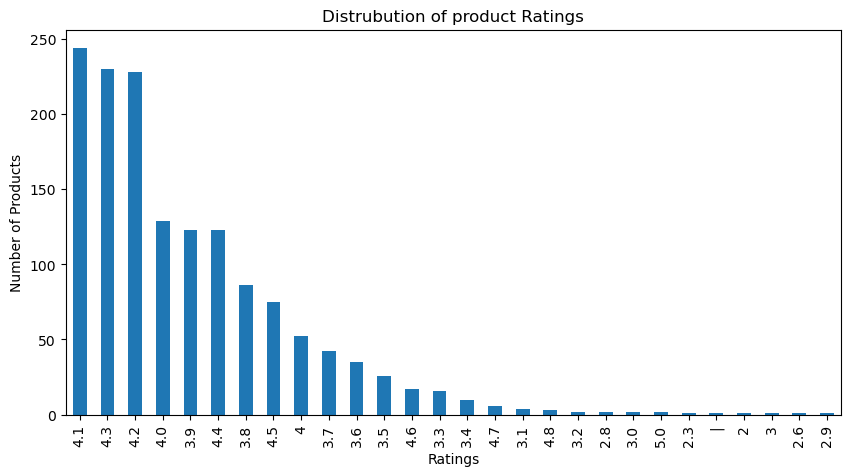

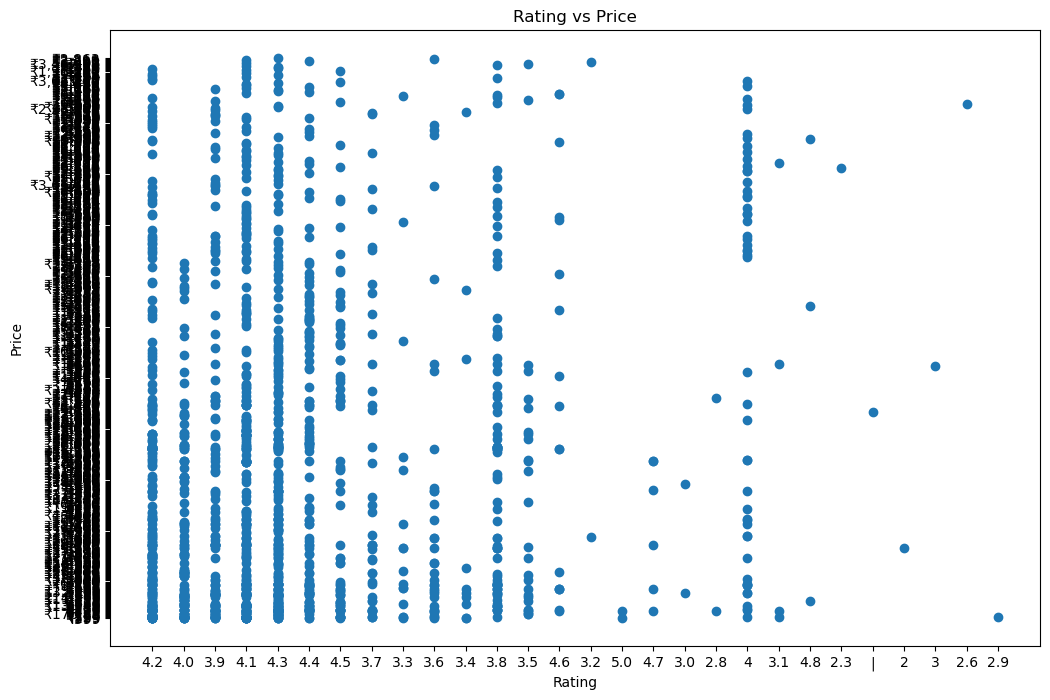

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

df = pd.read_csv("amazon.csv")
#print(df.info())
#print(df.head)
#print(df.describe())
#print(df.columns)
df = df.drop_duplicates()
df = df.dropna()
print(df)




plt.figure(figsize=(10,5))
df['rating'].value_counts().plot(kind='bar')

plt.title("Distrubution of product Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Products")

plt.show()



plt.figure(figsize=(12,8))
plt.scatter(df['rating'], df['discounted_price'])

plt.title("Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()


In [7]:
import csv 
import pandas as pd 

column=[]
col_num = int(input("enter your number of columns:"))
for i in range (col_num):
              col_name=str(input(f"Enter your column number {i+1}:"))
              column.append(col_name)

print(column)
              
Name=input("enter your name")
Age=input("enter your Age")
roll=input("enter your roll number")
with open("newdata.csv",mode="a",newline="") as file:
    writer = csv.writer(file)
    writer.writerow([Name,Age,roll])

df=pd.read_csv("newdata.csv")
print(df)





enter your number of columns: 2
Enter your column number 1: hadh
Enter your column number 2: jlhasdla


['hadh', 'jlhasdla']


enter your name ajildai
enter your Age jkadgu
enter your roll number akjshdua


            prannoy      16      2468
0           prannoy     123     12314
1          prannoy       12      2469
2          prannoy       18     14593
3             reva       21      2390
4             ishan      19      2678
5      Reva Mahajan      20      2239
6              praj     213     12314
7           prannot    sjad      asio
8               NaN     NaN       NaN
9               NaN     NaN       NaN
10          prannoy      19      2468
11          Prannoy      19      2468
12          prannoy  venkat        34
13  Prannoy venkat       17      2468
14          ajildai  jkadgu  akjshdua


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean data
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['discounted_price','rating'])

# Create price ranges
df['price_range'] = pd.cut(df['discounted_price'], bins=8)

# Calculate average rating per price range
price_rating = df.groupby('price_range', observed=False)['rating'].mean().reset_index()

# Plot bar graph
plt.figure(figsize=(10,5))

sns.barplot(
    x='price_range',
    y='rating',
    data=price_rating
)

plt.xticks(rotation=45)
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.title("Average Rating by Price Range")

plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("amazon.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("amazon.csv")
df.head()

df['actual_price']=pd.to_numeric(
    df['actual_price'].astype(str).str.replace("₹",'').str.replace(',','').astype(float)
)
df['discounted_price'] = pd.to_numeric(
    df['discounted_price'].astype(str).str.replace('₹','').str.replace(',','').astype(float)
    
)
df['savings']=df['actual_price']-df['discounted_price'] 
print(df.head())
df.to_csv('amazon.csv',index=False)
df['rating_count'] = pd.to_numeric(
    df['rating_count'].astype(str).str.replace(",", ""),
    errors='coerce'
)

df['rating_count'] = df['rating_count'].fillna(df['rating_count'].mean())


   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category  discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             399.0   
1  Computers&Accessories|Accessories&Peripherals|...             199.0   
2  Computers&Accessories|Accessories&Peripherals|...             199.0   
3  Computers&Accessories|Accessories&Peripherals|...             329.0   
4  Computers&Accessories|Accessories&Peripherals|...             154.0   

   actual_price discount_percentage rating rating_count  \
0        1099.0                 64%    4.2       24,269   
1         349.0             

In [31]:
df['rating_count'].head()
df.to_csv('amazon.csv',index=False)